In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer




In [34]:
df= pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])


In [35]:
df.shape

(891, 3)

# Drop all row 
-> with no values 

In [36]:
df.dropna(inplace=True)

In [37]:
df.shape


(714, 3)

# total 3 column 
    # age and fare 
    

In [38]:
X= df.iloc[:, 1:] # age and fare
y = df.iloc[:, 0] # Survived 

In [39]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [41]:

clf = DecisionTreeClassifier()

In [42]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [43]:

accuracy_score(y_test,y_pred)

0.6293706293706294

# 10 times score valdiate 

In [44]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.624706572769953)

# ordinal 
    *  something you define in oder 
    *  Good better best 

In [45]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')  # quantile , kmean , uniform your choice
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [46]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]), # intede of cloumn age index is 0 
    ('second',kbin_fare,[1]) # intede of cloumn fare index is 1
])

In [47]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [48]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [49]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', n_bins=15)

# bin for 

In [50]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [51]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

Tranformer 

In [52]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [53]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [54]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
49,18.0,2.0,17.8000,7.0,"(16.0, 19.0]","(14.454, 18.75]"
68,17.0,2.0,7.9250,3.0,"(16.0, 19.0]","(7.896, 8.158]"
251,29.0,7.0,10.4625,4.0,"(28.0, 30.0]","(8.158, 10.5]"
518,36.0,10.0,26.0000,9.0,"(35.0, 38.0]","(18.75, 26.0]"
476,34.0,9.0,21.0000,8.0,"(32.0, 35.0]","(18.75, 26.0]"


In [55]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [56]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [57]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345266040688575)

In [58]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\manis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6387128325508606


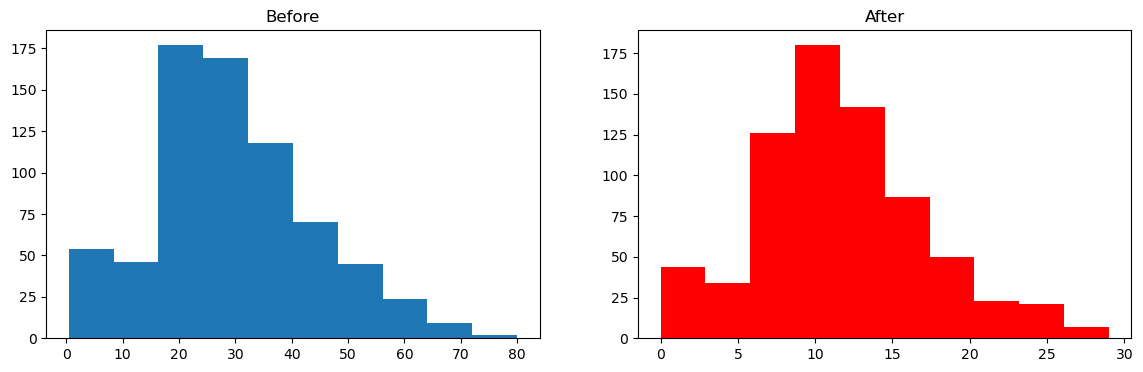

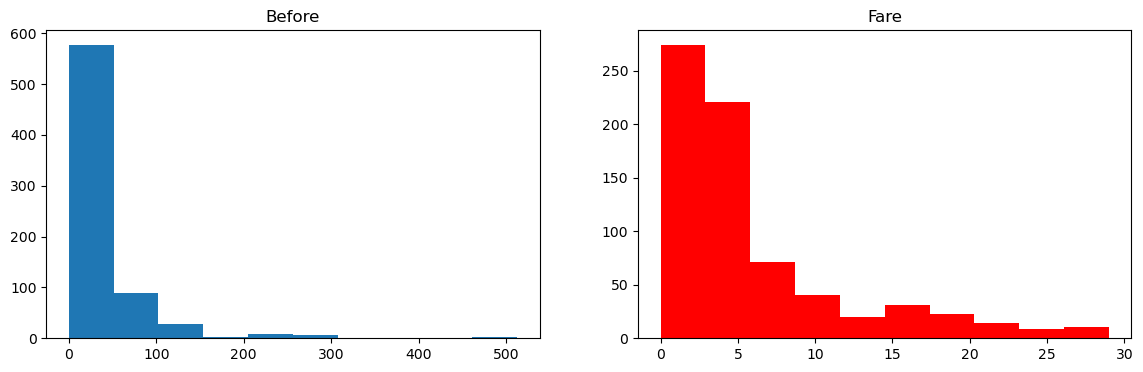

In [62]:
discretize(30,'kmeans')